In [1]:
import torch

In [2]:
model_path = '../models/rnn_seq2seq_attn.pt'

In [3]:
### Select device (GPU) ###

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'


print('Selected device:', device)

Selected device: cuda


In [4]:
import pandas as pd

### Reading data set ###

df = pd.read_csv('../data-sets/eng-nld.txt', sep='\t', header=None, usecols=[0, 1], names=['ENG', 'NLD'], dtype='string')
df.dropna()


print(df.info())
print()
print(df.sample())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76158 entries, 0 to 76157
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ENG     76158 non-null  string
 1   NLD     76158 non-null  string
dtypes: string(2)
memory usage: 1.2 MB
None

                                      ENG                                NLD
56472  The sky was filled with airplanes.  De lucht was vol met vliegtuigen.


In [5]:
import numpy as np
from nltk import word_tokenize

### Preprocessing ###

train_frac = 0.8
max_size = 20

sos_token = "<sos>"
eos_token = "<eos>"


# Tokenize
df['eng_tokens'] = df['ENG'].apply(lambda x: [sos_token] + word_tokenize(x.lower()) + [eos_token])
df['nld_tokens'] = df['NLD'].apply(lambda x: [sos_token] + word_tokenize(x.lower()) + [eos_token])

# Trim
df = df.drop(df[
    (df['eng_tokens'].map(len) > max_size) | 
    (df['nld_tokens'].map(len) > max_size)
].index)

# Split
df = df.sample(frac=1).reset_index(drop=True)
split = int(train_frac * len(df))

train_data = df.iloc[:split, :]
test_data  = df.iloc[split:, :]
test_data.reset_index(drop=True, inplace=True)


print('Total rows from file:', len(df))
print('Total rows of train data::', len(train_data))
train_data

Total rows from file: 75985
Total rows of train data:: 60788


,ENG,NLD,eng_tokens,nld_tokens
0,How did you end up here?,Hoe ben je hier beland?,"[<sos>, how, did, you, end, up, here, ?, <eos>]","[<sos>, hoe, ben, je, hier, beland, ?, <eos>]"
1,Tom told me to head north.,Tom zei me dat ik naar het noorden moest gaan.,"[<sos>, tom, told, me, to, head, north, ., <eos>]","[<sos>, tom, zei, me, dat, ik, naar, het, noor..."
2,I didn't buy you a Christmas present.,Ik heb geen kerstcadeau voor je gekocht.,"[<sos>, i, did, n't, buy, you, a, christmas, p...","[<sos>, ik, heb, geen, kerstcadeau, voor, je, ..."
3,Tom said that he's glad that that nobody was i...,Tom zei dat hij blij is dat niemand bij het on...,"[<sos>, tom, said, that, he, 's, glad, that, t...","[<sos>, tom, zei, dat, hij, blij, is, dat, nie..."
4,Tom is lying.,Tom liegt.,"[<sos>, tom, is, lying, ., <eos>]","[<sos>, tom, liegt, ., <eos>]"
...,...,...,...,...
60783,Tom and Mary met in Boston three years ago.,Tom en Maria hebben elkaar drie jaar geleden i...,"[<sos>, tom, and, mary, met, in, boston, three...","[<sos>, tom, en, maria, hebben, elkaar, drie, ..."
60784,Tom barely speaks to me anymore.,Tom praat nauwelijks meer tegen me.,"[<sos>, tom, barely, speaks, to, me, anymore, ...","[<sos>, tom, praat, nauwelijks, meer, tegen, m..."
60785,Thank you. We'll do our best.,Bedankt. We zullen ons best doen.,"[<sos>, thank, you, ., we, 'll, do, our, best,...","[<sos>, bedankt, ., we, zullen, ons, best, doe..."
60786,I ate a hamburger at McDonald's.,Ik heb een hamburger gegeten bij McDonald's.,"[<sos>, i, ate, a, hamburger, at, mcdonald, 's...","[<sos>, ik, heb, een, hamburger, gegeten, bij,..."


In [6]:
import torchtext

min_freq  = 2
unk_token = '<unk>'
pad_token = '<pad>'

special_tokens = [unk_token, pad_token, sos_token, eos_token]


eng_vocab = torchtext.vocab.build_vocab_from_iterator(
    df['eng_tokens'],
    min_freq=min_freq,
    specials=special_tokens
)


nld_vocab = torchtext.vocab.build_vocab_from_iterator(
    df['nld_tokens'],
    min_freq=min_freq,
    specials=special_tokens
)

eng_vocab.set_default_index(eng_vocab[unk_token])
nld_vocab.set_default_index(nld_vocab[unk_token])


print('Unique tokens in \'eng_tokens\' column:', len(eng_vocab))
print('Unique tokens in \'nld_tokens\' column:', len(nld_vocab))

Unique tokens in 'eng_tokens' column: 6693
Unique tokens in 'nld_tokens' column: 8551


In [7]:
import random
import numpy as np

### Vectorize data set ###

eng_pad_index = eng_vocab[pad_token]
nld_pad_index = nld_vocab[pad_token]


def build_dataset(subset):
    X = np.zeros((len(subset), max_size), dtype=np.int32)
    Y = np.zeros((len(subset), max_size), dtype=np.int32)
        
    for ix, row in subset.iterrows():
        eng_ixs = eng_vocab.lookup_indices(row['eng_tokens'])
        eng_ixs = eng_ixs + [eng_pad_index] * (max_size - len(eng_ixs))

        nld_ixs = nld_vocab.lookup_indices(row['nld_tokens'])
        nld_ixs = nld_ixs + [nld_pad_index] * (max_size - len(nld_ixs))

        X[ix] = eng_ixs
        Y[ix] = nld_ixs

    X = torch.tensor(X, dtype=torch.long)
    Y = torch.tensor(Y, dtype=torch.long)

    return X, Y


Xtr, Ytr = build_dataset(train_data)
Xte, Yte = build_dataset(test_data)


print('Xtr shape:', Xtr.shape)
print()
ix = random.randint(0, len(Xtr))
print(Xtr[ix].tolist())
print(Ytr[ix].tolist())
print()
print(eng_vocab.lookup_tokens(Xtr[ix].tolist()))
print(nld_vocab.lookup_tokens(Ytr[ix].tolist()))


Xtr shape: torch.Size([60788, 20])

[2, 8, 2284, 11, 40, 1850, 84, 4, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[2, 11, 2392, 7, 83, 14, 2121, 4, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

['<sos>', 'the', 'mayor', 'is', 'not', 'available', 'now', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
['<sos>', 'de', 'burgemeester', 'is', 'nu', 'niet', 'beschikbaar', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


In [8]:
import torch.nn as nn

### Bidirection Encoder ###

class Encoder(nn.Module):

    def __init__(self, vocab_size, emb_dim, hidden_size, n_layers=1, dropout=0):
        super(Encoder, self).__init__()

        self.n_layers    = n_layers

        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.GRU(emb_dim, hidden_size, n_layers, batch_first=True, dropout=dropout, bidirectional=True)

        self.dropout    = nn.Dropout(dropout)
        

    def forward(self, input):
        # input = [batch size, sequence length]

        embeddings = self.dropout(self.embeddings(input))
        # embeddings = [batch size, sequence length, embedding dim]

        output, hidden = self.rnn(embeddings)
        # output = [batch size, sequence length, 2 * hidden size]
        # hidden = [2 * n layers, batch size, hidden size]

        return output, hidden

In [9]:
import torch.nn as nn
import torch.nn.functional as F

### Bahdanau Attention mechanism ###

class Attention(nn.Module):

    def __init__(self, hidden_size):
        super(Attention, self).__init__()

        self.w = nn.Linear(hidden_size*2, hidden_size)
        self.v = nn.Linear(hidden_size, 1)


    def forward(self, hidden, encodings):
        # hidden    = [n layers, batch size, hidden size * 2]
        # encodings = [batch size, input sequence length, hidden size * 2]

        hidden = hidden.permute(1, 0, 2)
        # hidden = [batch size, n layers, hidden size * 2]

        sequence_length = encodings.shape[1]
        hidden = hidden[:, -1, :].unsqueeze(1).repeat(1, sequence_length, 1)
        # hidden = [batch size, input sequence length, hidden size * 2]

        scores = self.v(torch.tanh(self.w(torch.add(hidden, encodings))))
        # scores = [batch size, input sequence length, 1]

        scores = scores.squeeze(2)
        # scores = [batch size, input sequence length]

        weights = F.softmax(scores, dim=-1)
        # weights = [batch size, input sequence length]

        weights = weights.unsqueeze(1)
        # weights = [batch size, 1, input sequence length]

        return  weights

In [10]:
import torch.nn as nn

class Decoder(nn.Module):
    
    def __init__(self, vocab_size, emb_dim, hidden_size, n_layers=1, dropout=0):
        super(Decoder, self).__init__()

        self.vocab_size = vocab_size

        self.attention  = Attention(hidden_size)
        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.GRU(emb_dim + hidden_size*2, hidden_size*2, n_layers, batch_first=True, dropout=dropout)
        self.fc         = nn.Linear(hidden_size*2, vocab_size)

        self.dropout    = nn.Dropout(dropout)


    def forward(self, input, hidden, encodings):
        # input     = [batch size]
        # hidden    = [n layers, batch size, hidden size * 2]
        # encodings = [batch size, input sequence length, hidden size * 2]

        input = input.unsqueeze(1)
        # input = [batch size, 1]

        embeddings = self.dropout(self.embeddings(input))
        # embeddings = [batch size, 1, embedding dim]

        att_weights = self.attention(hidden, encodings)
        # att_weights = [batch size, 1, input sequence length]

        weighted_vectors = torch.bmm(att_weights, encodings)
        # context = [batch size, 1, hidden size * 2]
        
        rnn_input = torch.cat((embeddings, weighted_vectors), dim=2)
        # rnn_input = [batch size, 1, embedding dim + hidden size * 2]

        output, hidden = self.rnn(rnn_input, hidden)
        # output = [batch size, 1, hidden size]
        # hidden = [n layers, batch size, hidden size]

        prediction = self.fc(output.squeeze(1))
        # prediction = [batch size, vocab size]

        return prediction, hidden

In [11]:
import re
import torch.nn as nn

class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
    
    
    def forward(self, source, target, forced_teatching_ratio=0):
        # source = [batch size, sequence length]
        # target = [batch size, sequence length]

        batch_size        = target.shape[0]
        sequence_length   = target.shape[1]
        target_vocab_size = self.decoder.vocab_size


        #### 1. Encoding ###
        encodings, hidden = self.encoder(source)
        # encodings = [batch size, sequence length, 2 * hidden size]
        # hidden    = [2 * n layers, batch size, hidden size]


        ### 2. Decoding ###
        input = target[:, 0] # first input to the decoder is the <sos> tokens
        outputs = torch.zeros(sequence_length, batch_size, target_vocab_size).to(device)
        # input = [batch size]
        # outputs = [sequence length, batch size, vocab length]

        hidden = hidden.view(self.encoder.n_layers, 2, batch_size, hidden.shape[2])
        hidden = torch.cat((hidden[:, 0, :, :], hidden[:, 1, :, :]), dim=2)
        # hidden = [n layers, batch size, 2 * hidden size]
        
        for i in range(1, sequence_length):
            output, hidden = self.decoder(input, hidden, encodings)
            # output = [batch size, vocab size]
            # hidden = [n layers, batch size, 2 * hidden size]

            outputs[i] = output
            
            if random.random() < forced_teatching_ratio:
                input = target[:, i] # force teach
            else:
                input = torch.argmax(output, dim=1)
        
        outputs = outputs.permute(1, 2, 0)
        # outputs = [batch size, vocab size, sequence length]
        
        return outputs


    @torch.inference_mode()
    def translate(self, sentence, max_output_length=20):
        self.eval()
        
        nld_sos_index = nld_vocab[sos_token]
        nld_eos_index = nld_vocab[eos_token]

        tokens = [sos_token] + word_tokenize(sentence.lower()) + [eos_token]
        ixs = eng_vocab.lookup_indices(tokens)

        tensor = torch.tensor(ixs).unsqueeze(0).to(device)
        tensor.unsqueeze(0)
        # tensor = [1, sentence length, vocab size]

        encodings, hidden = self.encoder(tensor)
        # encodings = [1, sequence length, 2 * hidden size]
        # hidden    = [2 * n layers, 1, hidden size]

        hidden = hidden.view(self.encoder.n_layers, 2, 1, hidden.shape[2])
        hidden = torch.cat((hidden[:, 0, :, :], hidden[:, 1, :, :]), dim=2)
        # hidden = [n layers, 1, 2 * hidden size]

        indices = [nld_sos_index]
        for _ in range(max_output_length):
            inputs_tensor = torch.tensor(indices[-1]).unsqueeze(0).to(device)
            output, hidden = self.decoder(inputs_tensor, hidden, encodings)
            # output = [1, vocab size]
            # hidden = [n layers, 1, 2 * hidden size]

            output = output.squeeze(0)
            # output = [vocab size]

            prediction = torch.argmax(output).item()
            
            indices.append(prediction)
            if(prediction == nld_eos_index):
                break
        
        tokens = nld_vocab.lookup_tokens(indices)
        tokens = [t for t in tokens if t not in (eos_token, sos_token)]
        sentence = ' '.join(tokens).capitalize()
        sentence = re.sub(r'\s+([.,!?])', r'\1', sentence)

        return sentence

In [12]:
emb_dim     = 300
hidden_size = 512
n_layers    =   2
dropout     = 0.5

encoder = Encoder(len(eng_vocab), emb_dim, hidden_size, n_layers=n_layers, dropout=dropout)
decoder = Decoder(len(nld_vocab), emb_dim, hidden_size, n_layers=n_layers, dropout=dropout)
model   = Seq2Seq(encoder, decoder).to(device)

print('Total parameters:', sum(p.numel() for p in model.parameters()))

Total parameters: 34605432


In [13]:
import os.path

if os.path.isfile(model_path):
    print('Found saved model on', model_path)
    model.load_state_dict(torch.load(model_path))

In [14]:
lr = 0.0001


def forced_teaching_ratio(current_epoch, total_epochs, initial_ratio=0.9, final_ratio=0):
    # Gradually lower forced teaching ratio throughout the training
    progress = current_epoch / total_epochs
    return initial_ratio - (initial_ratio - final_ratio) * progress

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [15]:
import torch.nn.functional as F

def log_statistics(parameters, eval_batch_size=3200):
    gradients_norm = torch.tensor(
        [torch.norm(param.grad).item() for param in parameters if param.grad is not None]
    ).norm().item()
    
    inputs = torch.zeros((eval_batch_size, max_size), dtype=torch.long).to(device)
    inputs[:, 0] = nld_vocab[sos_token]

    model.eval()
    with torch.inference_mode():
    
        # Sample larger train-batch
        ix = torch.randint(0, Xtr.shape[0], (eval_batch_size,))
        Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)
        
        outputs = model(Xb, inputs)
        loss = F.cross_entropy(outputs, Yb)

        # Sample larger test-batch
        ix = torch.randint(0, Xte.shape[0], (eval_batch_size,))
        Xb, Yb = Xte[ix].to(device), Yte[ix].to(device)

        outputs = model(Xb, inputs)
        test_loss = F.cross_entropy(outputs, Yb)
        
        return loss.item(), test_loss.item(), gradients_norm

In [16]:
from tqdm import trange

### Train network ###

epoch_count       = []
ratio_values      = []
train_loss_values = []
test_loss_values  = []
gradients_norm    = []

epochs            = 50000
batch_size        =    64


for epoch in trange(epochs):
    model.train()
    ft_ratio = forced_teaching_ratio(epoch, epochs)

    # Sample mini-batch and send to gpu
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)

    output = model(Xb, Yb, ft_ratio) # Do the forward pass
    loss = criterion(output, Yb)     # Calculate the loss
    optimizer.zero_grad()            # Reset parameters
    loss.backward()                  # Backpropagation
    optimizer.step()                 # Update parameters


    # Report progression every so often
    if ((epoch + 1) % (epochs / 50) == 0):
        train_loss, test_loss, grad_norm = log_statistics(model.parameters())

        epoch_count.append(epoch)
        train_loss_values.append(train_loss)
        test_loss_values.append(test_loss)
        gradients_norm.append(grad_norm)
        ratio_values.append(ft_ratio)


# Print final results
print()
print('Final training loss:', round(train_loss, 3))
print('Final test loss:    ', round(test_loss, 3))

  0%|          | 0/50000 [00:00<?, ?it/s]

100%|██████████| 50000/50000 [1:21:09<00:00, 10.27it/s]  


Final training loss: 0.67
Final test loss:     1.365


In [20]:
torch.save(model.state_dict(), model_path)

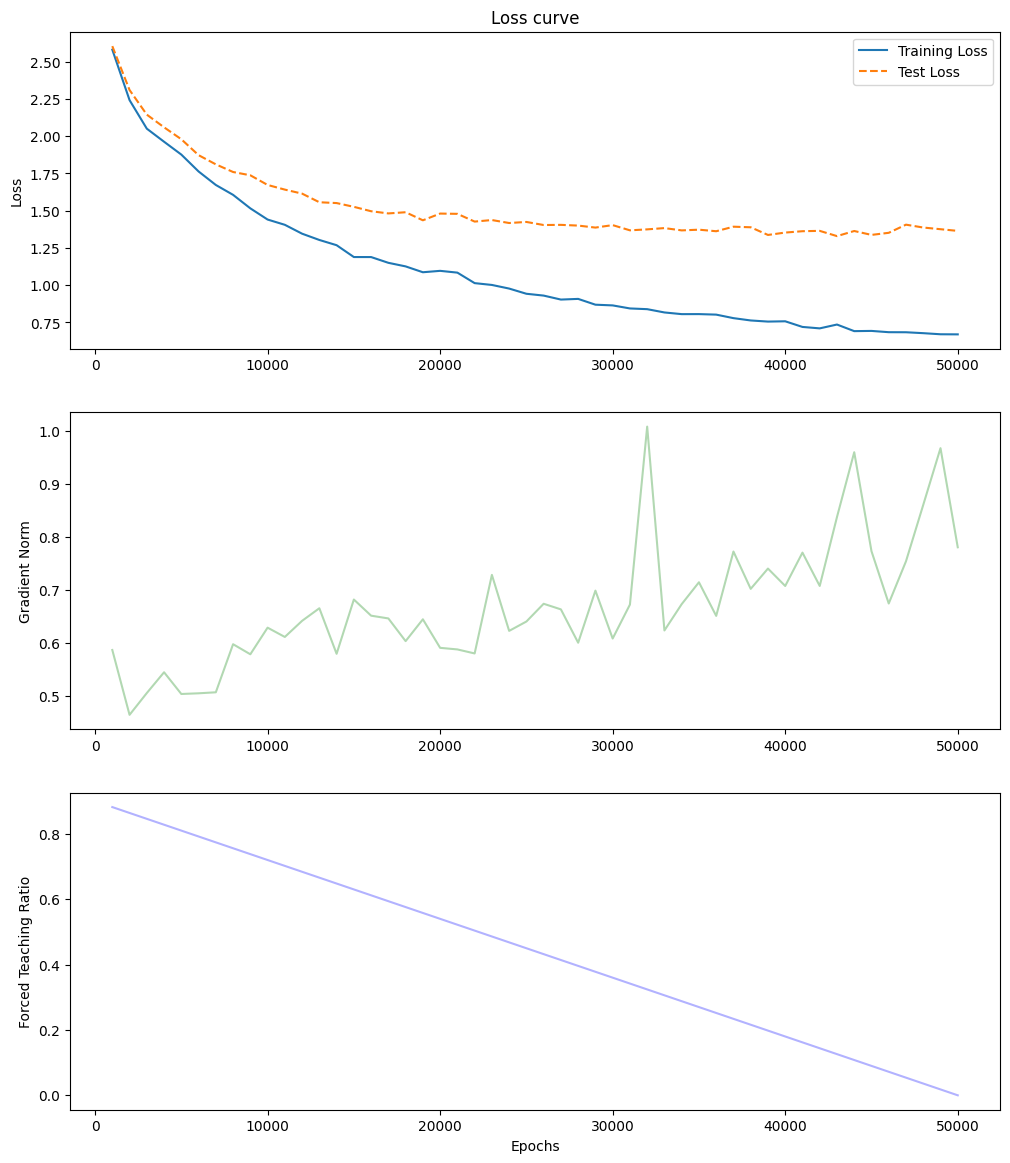

In [21]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14))

# Plot training and test loss on the first subplot
ax1.plot(epoch_count, train_loss_values, label='Training Loss')
ax1.plot(epoch_count, test_loss_values, label='Test Loss', linestyle='--')
ax3.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Loss curve')
ax1.legend(loc='upper right')

# Plot gradient norm on the second subplot
ax2.plot(epoch_count, gradients_norm, 'g', alpha=0.3)
ax3.set_xlabel('Epochs')
ax2.set_ylabel('Gradient Norm')

# Plot forced teaching ratio decay on the third subplot
ax3.plot(epoch_count, ratio_values, 'b', alpha=0.3)
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Forced Teaching Ratio')

plt.show()

In [22]:
### Use model ###

print(model.translate('Go!'))
print(model.translate('It\'s Fine.'))
print(model.translate('I\'m very happy.'))
print(model.translate('He\'s very sad.'))
print(model.translate('That man is wearing a white shirt.'))
print(model.translate('He\'s afraid of spiders.'))
print(model.translate('He\'s going home to his wife.'))
print(model.translate('Those guys are walking to work.'))
print(model.translate('I\'m not going with you today.'))
print(model.translate('My girlfriend will not come over tomorrow.'))
print(model.translate('He bought his friends a nice present for christmas.'))


Ga!
Het is.. <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
Ik ben gelukkig.
Hij erg intelligent.
Die draagt ​​een witte overhemd aan.
Hij bang voor spinnen.
Hij gaat naar zijn vrouw.
Lopen lopen werken het werk werk. <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
Vandaag ga vandaag met je vandaag.
Mijn morgen morgen morgen morgen.
Hij kocht vrienden mooie cadeau voor voor voor.
